In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

In [9]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        def in_range(t):
            t_clipped = jnp.clip(t, self.t_obs[0], self.t_obs[-1])

            idx = jnp.searchsorted(self.t_obs, t_clipped, side="left")
            idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

            t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
            y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]

            w = (t_clipped - t0) / (t1 - t0 + 1e-12)
            return (1.0 - w) * y0 + w * y1

        return jax.lax.cond(
            t > self.t_obs[-1],
            lambda _: jnp.zeros_like(self.y_obs[0]),
            lambda _: in_range(t),
            operand=None,
        )
    
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)

    def __call__(self, t, state, args):
        obs_fun = args

        return jax.lax.cond(
                t > obs_fun.t_obs[-1],
                lambda _: self.call_normal(t, state, args),
                lambda _: self.call_pem(t, state, args),
                operand=None,
            )


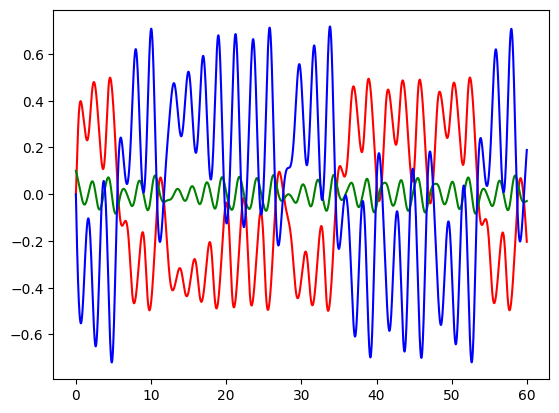

In [10]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 60

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [11]:
T_MAX = 60
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.05))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train = sol_train.ys[::5]
    t_train = sol_train.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol_val.ys[::2]
    t_val = sol_val.ts[::2]

    return x_train, t_train, x_val, t_val, sol_train, sol_val
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


In [12]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0., 0., 0.], key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_5_ude_jax.eqx", ude_pem)

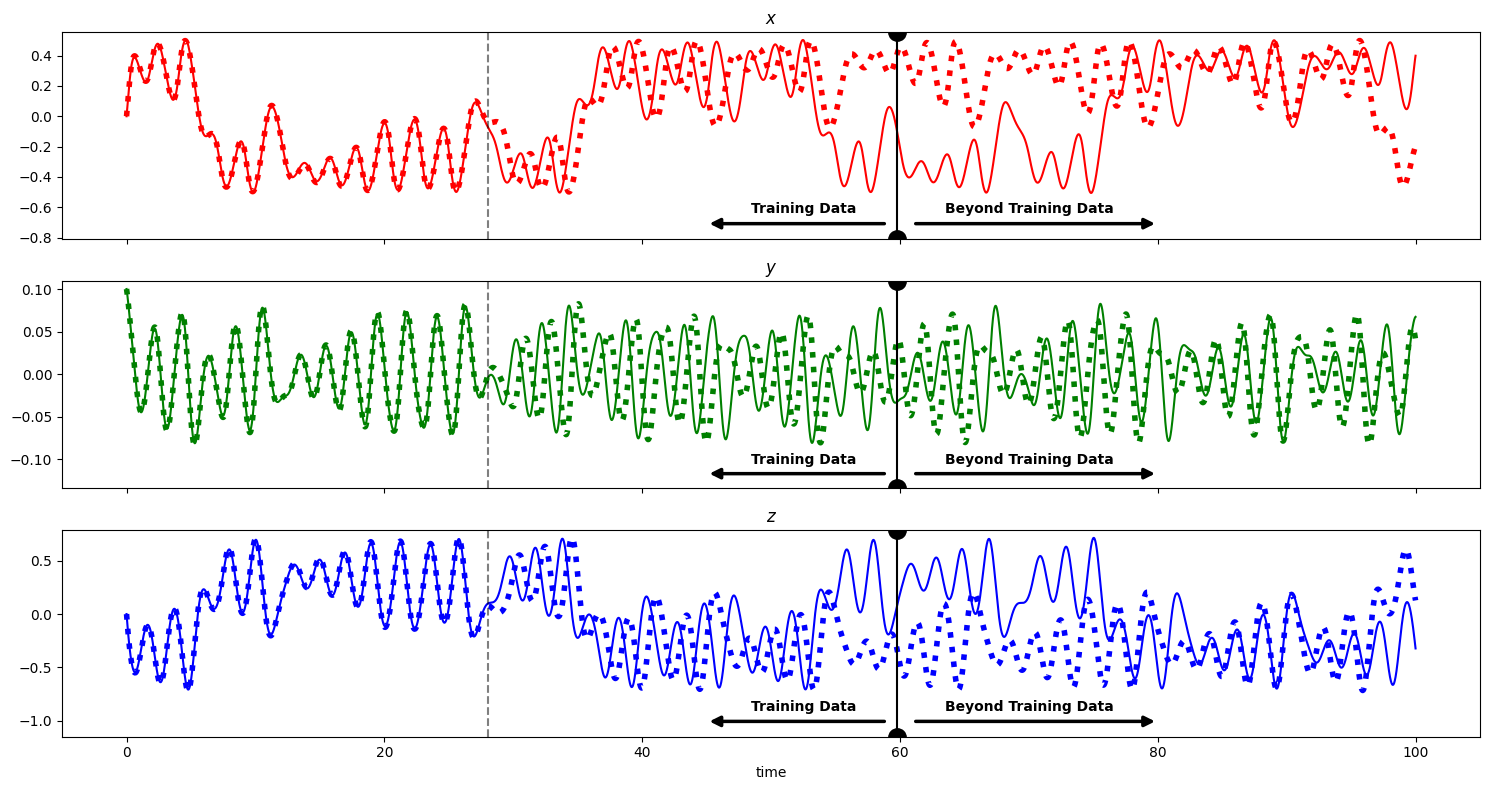

In [25]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 100

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp, saveat=saveat, stepsize_controller=stepper, max_steps=10000).ys

N = 28


for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval, traj_final[:, i], color=col_dict[i],)
    plt.plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=4)
    plt.axvline(t_train[-1], color="k", label="Last Training Set Point", marker=".", markersize=25)
    plt.title(f"${var_dict[i]}$")
    plt.axvline(N, color="black", linestyle="--", label="Divergence Time", linewidth=1.5, alpha=0.5)

    y_min = min(jnp.min(traj_true[:, i]), jnp.min(traj_final[:, i]))
    plt.ylim(y_min * 1.6, None)
    
    plt.annotate('', xy=(80, y_min+y_min*0.4), xytext=(61, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(70, y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold")

    plt.annotate('', xy=(59, y_min+y_min*0.4), xytext=(45, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(52.5, y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold" )

plt.xlabel("time")

plt.tight_layout()
plt.show()